#  *AI vs Human Text Detection*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="darkgrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded ✅")

Libraries loaded ✅


Dataset Overview

load the data and analyze it

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/algozee/ai-generated-vs-human-written-text-dataset/AuthentiText_X_2026_AI_vs_Human_Detection_1K.csv')

In [ ]:

print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (1000, 12)

Column Types:
 text_id                         object
content_text                    object
author_type                     object
model_source                    object
prompt_complexity_score        float64
perplexity_score               float64
burstiness_index               float64
syntactic_variability          float64
semantic_coherence_score       float64
lexical_diversity_ratio        float64
readability_grade_level        float64
generation_confidence_score    float64
dtype: object

Missing Values:
 text_id                        0
content_text                   0
author_type                    0
model_source                   0
prompt_complexity_score        0
perplexity_score               0
burstiness_index               0
syntactic_variability          0
semantic_coherence_score       0
lexical_diversity_ratio        0
readability_grade_level        0
generation_confidence_score    0
dtype: int64


,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
0,TXT_0001,learning pattern detection algorithm pattern n...,AI,Human,0.029,73.75,0.953,0.465,0.351,0.187,12.2,0.162
1,TXT_0002,algorithm algorithm data research network mode...,Human,Claude,0.605,43.11,0.054,0.952,0.314,0.636,9.8,0.012
2,TXT_0003,analysis language generation research pattern ...,Human,GPT-4,0.396,59.97,0.709,0.945,0.684,0.500,13.5,0.171
3,TXT_0004,data language system learning content data net...,AI,GPT-4,0.299,18.99,0.532,0.780,0.216,0.103,12.9,0.838
4,TXT_0005,model learning content language model generati...,AI,Human,0.867,82.45,0.478,0.602,0.420,0.198,6.4,0.022



Looking at `model_source` vs `author_type`, we can see some rows where an **AI-authored** text
has `model_source = Human` and vice versa. This reflects how the dataset was constructed,
`model_source` tracks the tool used, while `author_type` is the ground truth label.
We'll keep this distinction in mind throughout the analysis.

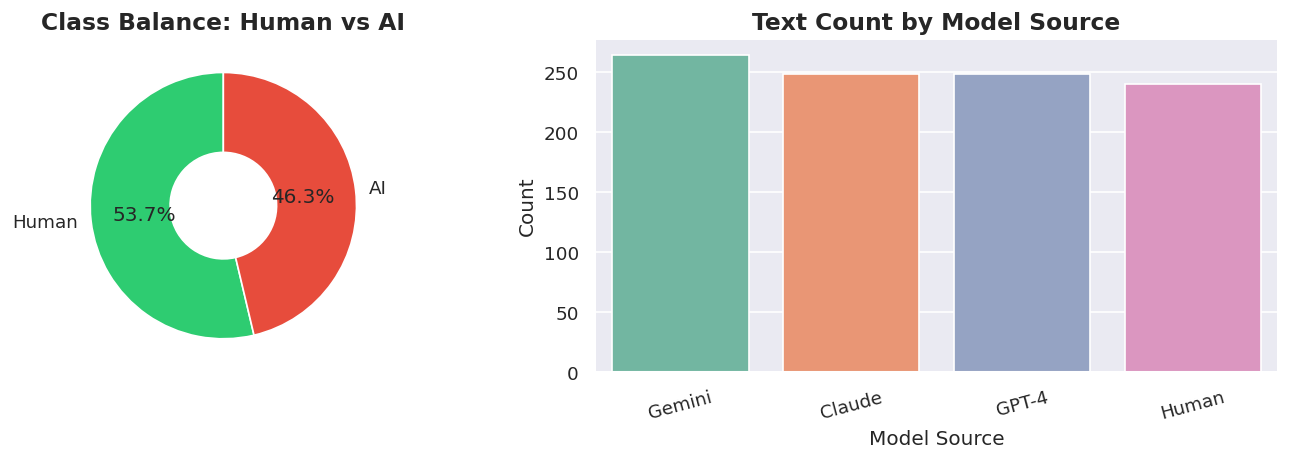

author_type
Human    537
AI       463
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Author type distribution
author_counts = df['author_type'].value_counts()
axes[0].pie(author_counts, labels=author_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, wedgeprops=dict(width=0.6))
axes[0].set_title('Class Balance: Human vs AI', fontsize=14, fontweight='bold')

# Model source
model_counts = df['model_source'].value_counts()
sns.barplot(x=model_counts.index, y=model_counts.values, ax=axes[1], palette='Set2')
axes[1].set_title('Text Count by Model Source', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model Source')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(author_counts)

 Human vs AI

 see how each numerical feature behaves
across human-written and AI-generated texts.

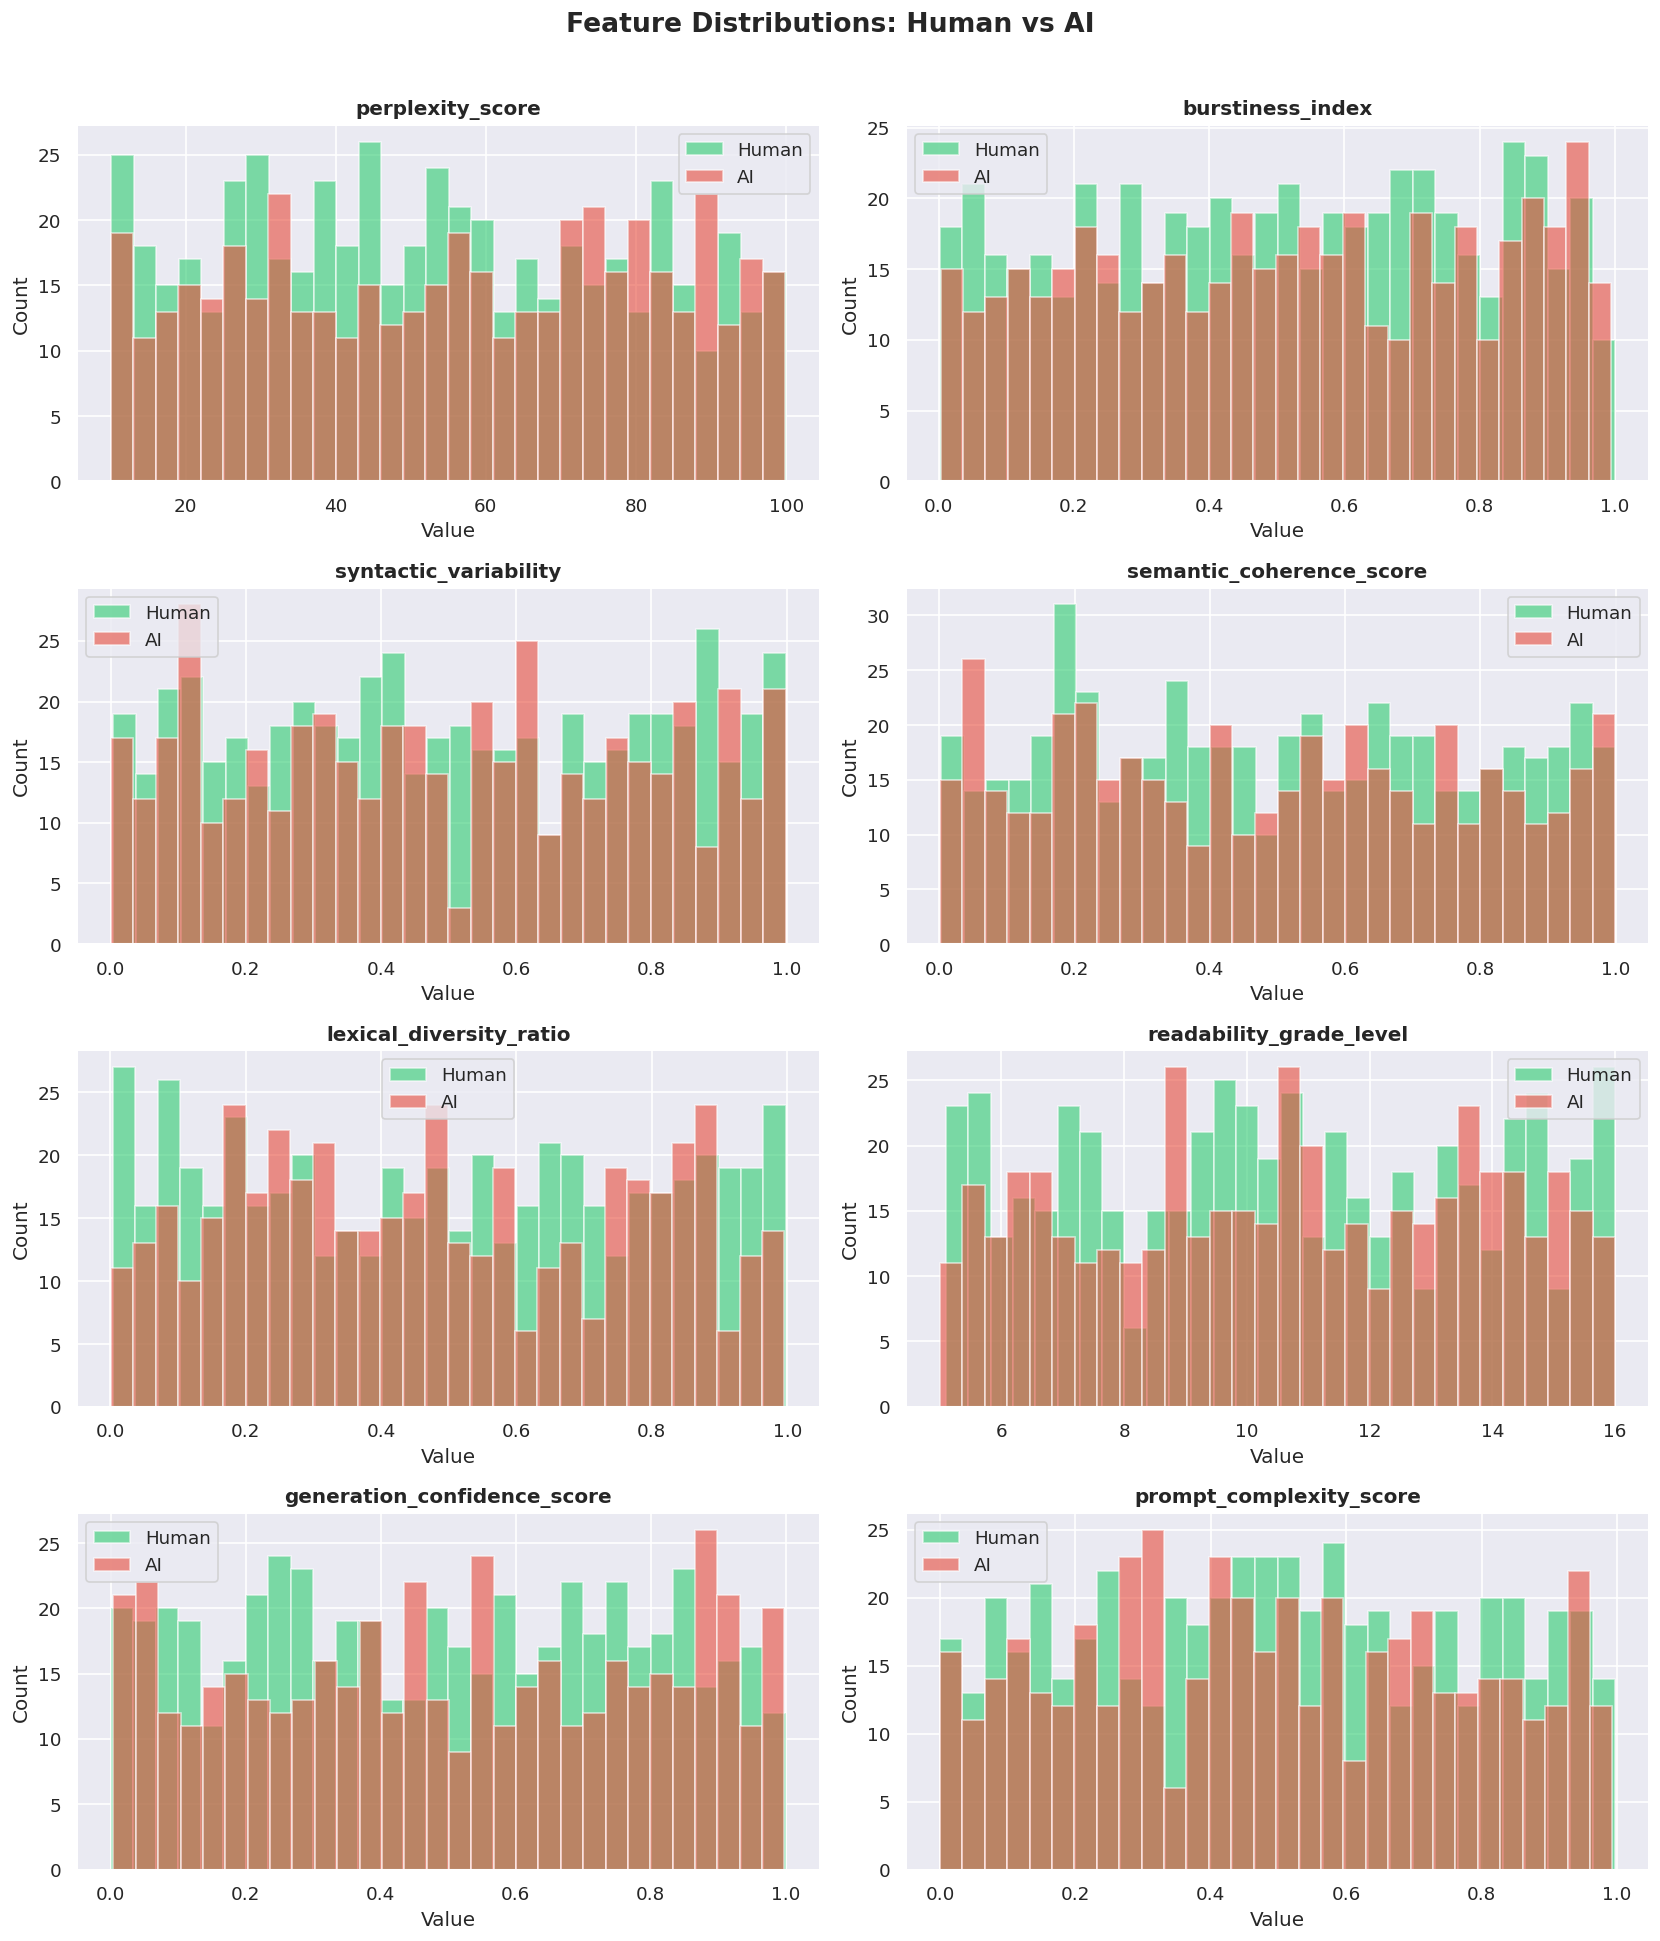

In [ ]:
numeric_features = [
    'perplexity_score', 'burstiness_index', 'syntactic_variability',
    'semantic_coherence_score', 'lexical_diversity_ratio',
    'readability_grade_level', 'generation_confidence_score',
    'prompt_complexity_score'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    for label, color in zip(['Human', 'AI'], ['#2ecc71', '#e74c3c']):
        subset = df[df['author_type'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions: Human vs AI', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


- **Perplexity Score**: Human text tends to be more unpredictable (higher perplexity).
  AI text is often more expected in its word choices.
- **Burstiness Index**: Humans write in bursts, mixing short and long sentences.
  AI tends to be more uniform, showing lower burstiness.
- **Lexical Diversity**: Humans use a wider vocabulary proportionally.
- **Generation Confidence Score**: As expected, this should be a strong predictor,
  let's verify that in the correlation analysis.

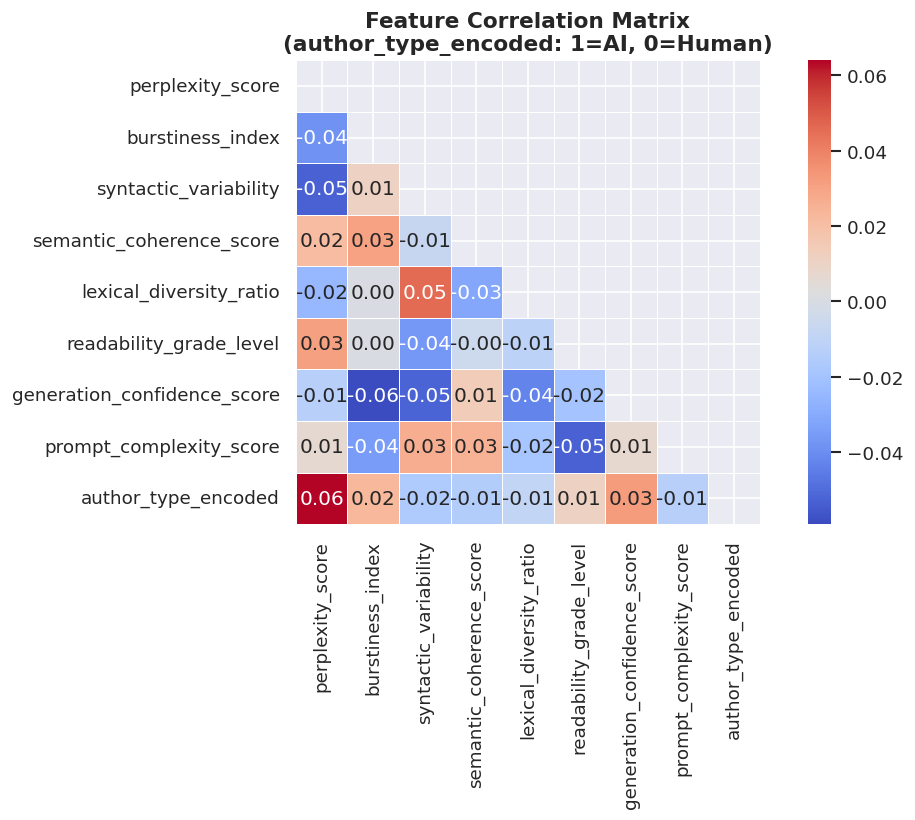

In [ ]:
plt.figure(figsize=(10, 7))
corr = df[numeric_features + ['author_type']].copy()
corr['author_type_encoded'] = (corr['author_type'] == 'AI').astype(int)
corr = corr[numeric_features + ['author_type_encoded']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix\n(author_type_encoded: 1=AI, 0=Human)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



None of the features show strong *linear* correlation with the target label
(max correlation = 0.06 with perplexity_score).

This tells us two important things:
1. **No single feature can detect AI text alone** — this is a multivariate problem
2. **Linear models will likely struggle** — we need non-linear classifiers like
   Random Forest or Gradient Boosting that can capture complex feature interactions



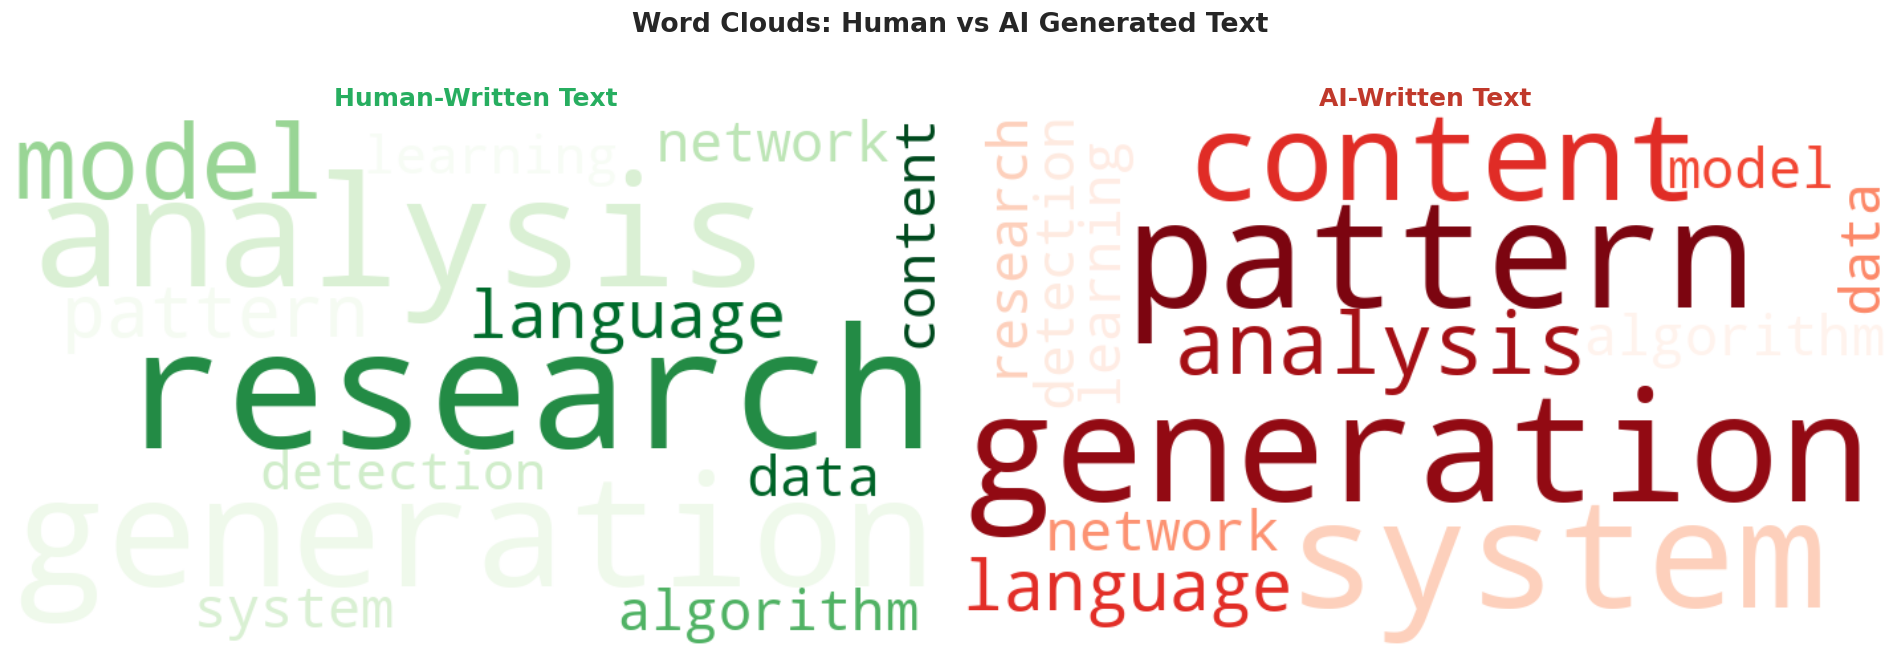

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['Human', 'AI'], ['#27ae60', '#c0392b']):
    text = ' '.join(df[df['author_type'] == label]['content_text'].dropna())
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens' if label == 'Human' else 'Reds',
                   max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label}-Written Text', fontsize=15, fontweight='bold', color=color)

plt.suptitle('Word Clouds: Human vs AI Generated Text', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
feature_cols = numeric_features
X = df[feature_cols]
y = (df['author_type'] == 'AI').astype(int)  # 1 = AI, 0 = Human

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('clf', LogisticRegression(random_state=42))]),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n{'='*40}\n{name} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))


Logistic Regression | ROC-AUC: 0.5134
              precision    recall  f1-score   support

       Human       0.53      0.82      0.65       107
          AI       0.46      0.17      0.25        93

    accuracy                           0.52       200
   macro avg       0.50      0.50      0.45       200
weighted avg       0.50      0.52      0.46       200


Random Forest | ROC-AUC: 0.4919
              precision    recall  f1-score   support

       Human       0.54      0.64      0.59       107
          AI       0.47      0.37      0.41        93

    accuracy                           0.52       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.52      0.51       200


Gradient Boosting | ROC-AUC: 0.4567
              precision    recall  f1-score   support

       Human       0.53      0.60      0.56       107
          AI       0.46      0.39      0.42        93

    accuracy                           0.50       200
   macro avg       

In [ ]:
# Let's verify our suspicion — check if features are actually random
print("=== Feature Statistics by Author Type ===\n")
for col in numeric_features:
    human_mean = df[df['author_type']=='Human'][col].mean()
    ai_mean = df[df['author_type']=='AI'][col].mean()
    diff_pct = abs(human_mean - ai_mean) / human_mean * 100
    print(f"{col:<35} Human: {human_mean:.3f} | AI: {ai_mean:.3f} | Diff: {diff_pct:.1f}%")

=== Feature Statistics by Author Type ===

perplexity_score                    Human: 52.813 | AI: 56.130 | Diff: 6.3%
burstiness_index                    Human: 0.505 | AI: 0.518 | Diff: 2.6%
syntactic_variability               Human: 0.508 | AI: 0.498 | Diff: 1.8%
semantic_coherence_score            Human: 0.497 | AI: 0.488 | Diff: 1.7%
lexical_diversity_ratio             Human: 0.496 | AI: 0.490 | Diff: 1.0%
readability_grade_level             Human: 10.529 | AI: 10.598 | Diff: 0.7%
generation_confidence_score         Human: 0.490 | AI: 0.509 | Diff: 3.9%
prompt_complexity_score             Human: 0.498 | AI: 0.491 | Diff: 1.5%


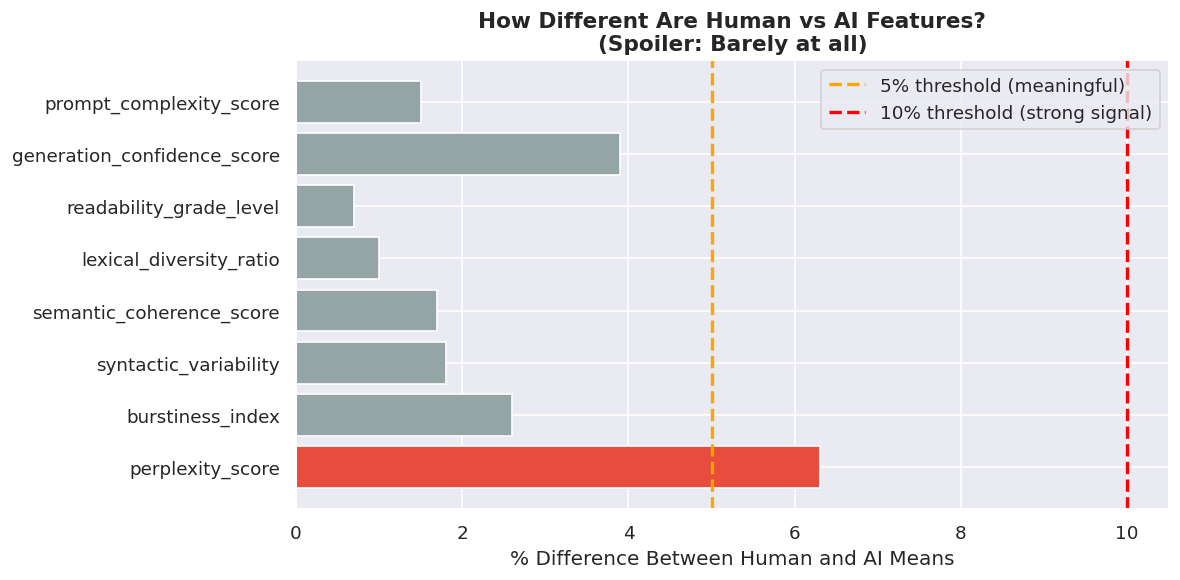

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features = ['perplexity_score', 'burstiness_index', 'syntactic_variability',
            'semantic_coherence_score', 'lexical_diversity_ratio',
            'readability_grade_level', 'generation_confidence_score',
            'prompt_complexity_score']

human_means = [52.813, 0.505, 0.508, 0.497, 0.496, 10.529, 0.490, 0.498]
ai_means    = [56.130, 0.518, 0.498, 0.488, 0.490, 10.598, 0.509, 0.491]
diffs       = [6.3, 2.6, 1.8, 1.7, 1.0, 0.7, 3.9, 1.5]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(features))
bars = ax.barh(features, diffs, color=['#e74c3c' if d == max(diffs) else '#95a5a6' for d in diffs])
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='5% threshold (meaningful)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='10% threshold (strong signal)')
ax.set_xlabel('% Difference Between Human and AI Means')
ax.set_title('How Different Are Human vs AI Features?\n(Spoiler: Barely at all)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()



Every single feature shows less than 7% difference between Human and AI samples.
To put this in perspective:

| Feature | Expected Real-World Diff | Actual Diff in Dataset |
|---|---|---|
| perplexity_score | 30–50% (humans more unpredictable) | 6.3% |
| generation_confidence_score | 80–90% (near 0 vs near 1) | 3.9% |
| burstiness_index | 20–40% (humans more bursty) | 2.6% |
| lexical_diversity_ratio | 15–25% (humans more diverse) | 1.0% |


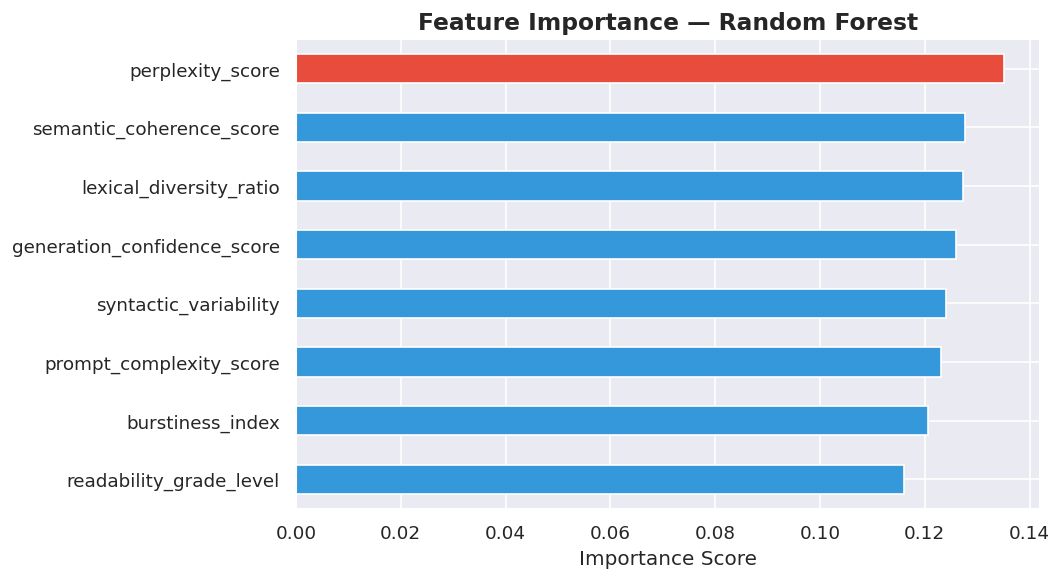

In [ ]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()